## Imports

In [15]:
import numpy as np
import json
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from teleportation_circuit import create_teleportation_circuit
from fidelity_analysis import compute_fidelity
from compute_error_bars import compute_error_bar

## Define Angles

In [16]:
angles = [
    0,
    np.pi/6,
    np.pi/4,
    np.pi/3,
    np.pi/2
]

## Simulator Setup

In [17]:
simulator = AerSimulator()

shots = 4096

sim_fidelities = []
sim_counts_list = []

## Run Simulator Experiments

In [18]:
for theta in angles:

    qc = create_teleportation_circuit(theta)

    job = simulator.run(qc, shots=shots)

    results = job.result()

    counts = results.get_counts()

    fidelity = compute_fidelity(counts)

    sim_fidelities.append(fidelity)

    sim_counts_list.append(counts)

In [19]:
print(sim_fidelities)
print(sim_counts_list)

[1.0, 1.0, 1.0, 1.0, 1.0]
[{'001': 1033, '000': 1038, '010': 1025, '011': 1000}, {'001': 1034, '000': 1003, '010': 996, '011': 1063}, {'001': 1021, '011': 1017, '000': 996, '010': 1062}, {'011': 1066, '000': 983, '010': 1010, '001': 1037}, {'010': 1019, '000': 1047, '011': 1007, '001': 1023}]


## Connect to IBM Quantum

In [20]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)


print(f"Trageting Backend: {backend.name}")
print("Backend version:", backend.version)
print("Number of qubits:", backend.num_qubits)
print("Number of Pending Jobs:", backend.status().pending_jobs)

Trageting Backend: ibm_marrakesh
Backend version: 2
Number of qubits: 156
Number of Pending Jobs: 0


## Hardware Execution

In [ ]:
hardware_fidelities = []
hardware_counts_list = []
hardware_errors = []

sampler = Sampler(mode=backend)

for theta in angles:

    qc = create_teleportation_circuit(theta)

    pm = generate_preset_pass_manager(backend=backend)

    isa_circuit = pm.run(qc)

    job = sampler.run([isa_circuit], shots=4096)

    result = job.result()

    counts = result[0].data.c.get_counts()

    fidelity = compute_fidelity(counts)

    error = compute_error_bar(fidelity, shots)

    hardware_fidelities.append(fidelity)

    hardware_counts_list.append(counts)

    hardware_errors.append(error)

## Plot Histogram Example

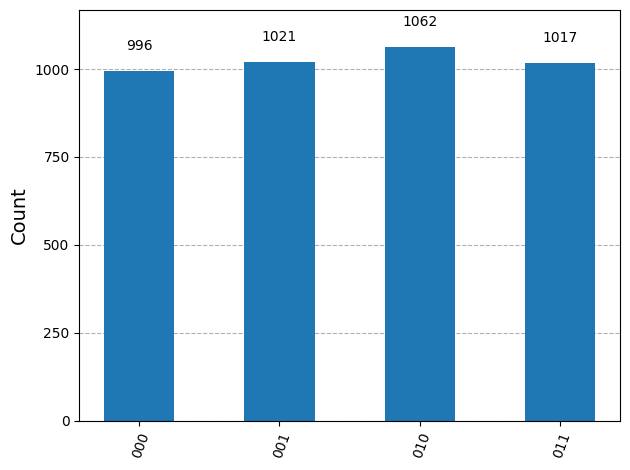

In [22]:
plot_histogram(sim_counts_list[2])

## Fidelity Plot

In [23]:
print(sim_fidelities)

[1.0, 1.0, 1.0, 1.0, 1.0]


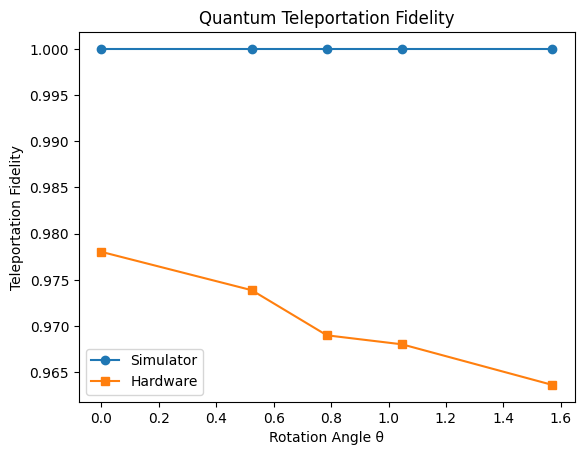

In [24]:
plt.plot(angles, sim_fidelities, marker='o', label="Simulator")
plt.plot(angles, hardware_fidelities, marker='s', label="Hardware")

plt.xlabel("Rotation Angle θ")
plt.ylabel("Teleportation Fidelity")
plt.title("Quantum Teleportation Fidelity")

plt.legend()

plt.show()

## Save Results

In [25]:
with open("results/simulator_results.json","w") as f:

    json.dump(sim_counts_list,f)


with open("results/hardware_results.json","w") as f:

    json.dump(hardware_counts_list,f)

## Statistical Error Bars

fidelity comes from binomial sampling:
$$ F = \frac{k}{N} $$

Standard deviation: 
$$ \sigma = \sqrt\frac{F(1 - F)}{N} $$

where
- F = fidelity
- N = shots

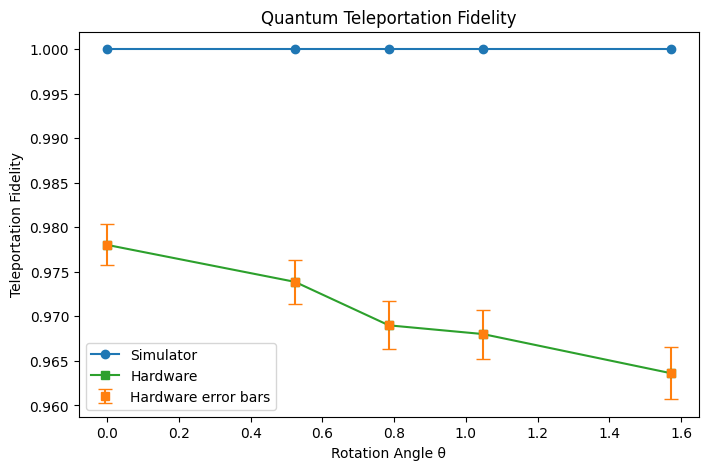

In [28]:
plt.figure(figsize=(8,5))

plt.plot(angles, sim_fidelities,
         marker='o',
         label="Simulator")

plt.errorbar(angles,
             hardware_fidelities,
             yerr=hardware_errors,
             fmt='s',
             capsize=5,
             label="Hardware error bars")

plt.plot(angles, hardware_fidelities, marker='s', label="Hardware")


plt.xlabel("Rotation Angle θ")
plt.ylabel("Teleportation Fidelity")

plt.title("Quantum Teleportation Fidelity")

plt.legend()

plt.show()